# Análisis de señales EEG adquiridas con BITalino

Este notebook procesa seis registros EEG adquiridos en archivos `.txt`, uno por cada condición experimental:

1. Basal / ojos cerrados con aislamiento parcial.
2. Ojos abiertos mirando un punto fijo.
3. Parpadeo.
4. Masticación.
5. Música relajante.
6. Música estresante.

El análisis está orientado a cumplir con los puntos solicitados en el laboratorio:

- Comparar potencia **alfa** en ojos abiertos vs. ojos cerrados usando PSD de Welch con ventanas de 2 s.
- Evaluar incremento de **beta** durante una condición de carga/estrés mediante **t-test pareado**.
- Detectar artefactos de parpadeo con umbral mayor a **80 µV** y contabilizarlos.
- Generar figuras y tablas para la sección de resultados del informe.

> **Importante:** antes de ejecutar el notebook, colocar los archivos `.txt` en la carpeta `data/raw/` y revisar la sección de configuración.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Instalación e importación de librerías

Ejecutar esta celda primero. Si alguna librería falta, descomentar la línea de instalación.

In [ ]:
# Si falta alguna librería, descomenta esta línea:
# !pip install numpy pandas scipy matplotlib

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch, butter, filtfilt, iirnotch, find_peaks
from scipy.stats import ttest_rel

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

## 2. Configuración del análisis

Edita esta celda según cómo estén guardados tus datos.

### Parámetros importantes

- `FS_HZ`: frecuencia de muestreo usada durante la adquisición.
- `INPUT_UNIT`: usa `"adc"` si los archivos contienen valores ADC de 0 a 1023. Usa `"uv"` si ya están en microvoltios.
- `EEG_COLUMN_INDICES`: columnas donde están los canales EEG dentro del `.txt`.

### Sobre las columnas

Si tus archivos tienen una sola señal EEG, usa:

```python
EEG_COLUMN_INDICES = {"EEG": -1}
```

Si tienes dos canales, por ejemplo Fp1 y Fp2, puedes usar:

```python
EEG_COLUMN_INDICES = {"Fp1": -2, "Fp2": -1}
```

El índice `-1` significa última columna, `-2` penúltima columna.

In [ ]:

# ==============================
# CONFIGURACIÓN DEL USUARIO
# ==============================

# Frecuencia de muestreo del BITalino
# Cambia este valor si adquirieron a 100 Hz, 250 Hz, 1000 Hz, etc.
FS_HZ = 1000

# Ruta principal en Google Drive
BASE_DIR = Path("/content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG")

# Si tus archivos .txt están directamente dentro de "Lab 7 EEG"
RAW_DIR = BASE_DIR

# Archivos de entrada
FILES = {
    "basal_ojos_cerrados": RAW_DIR / "Basal_1.txt",
    "ojos_abiertos": RAW_DIR / "Abrir_PFijo.txt",
    "parpadeo": RAW_DIR / "Parpadeo.txt",
    "masticacion": RAW_DIR / "Mastic.txt",
    "musica_relajante": RAW_DIR / "Music_Relax.txt",
    "musica_estresante": RAW_DIR / "Music_Estres.txt",
}

# Verificar que la carpeta existe
print("BASE_DIR existe:", BASE_DIR.exists())
print("RAW_DIR existe:", RAW_DIR.exists())

# Mostrar archivos .txt encontrados
print("\nArchivos .txt encontrados:")
for file in sorted(RAW_DIR.glob("*.txt")):
    print("-", file.name)

# Verificar rutas configuradas
print("\nArchivos configurados:")
for condition, path in FILES.items():
    print(condition, "->", path.name, "| Existe:", path.exists())

# ==============================
# CANALES EEG
# ==============================

EEG_COLUMN_INDICES = {
    "Fp1": -2,
    "Fp2": -1
  }



# ==============================
# CONVERSIÓN Y ESPECIFICACIONES
# ==============================

# Unidad de entrada:
# "adc"  -> valores crudos del ADC BITalino 10-bit
# "uv"   -> valores ya convertidos a microvoltios
# "auto" -> intenta decidir automáticamente
INPUT_UNIT = "auto"

# Especificaciones dadas del canal EEG BITalino
GAIN = 40000
ADC_BITS = 10
LSB_UV = 3.2   # aproximadamente 3.2 µV/LSB

# ==============================
# FILTROS
# ==============================

# El BITalino ya tiene filtro hardware 0.8-48 Hz.
# Este filtro digital se usa como complemento para estandarizar el análisis.
APPLY_BANDPASS = True
BANDPASS_LOW_HZ = 0.8
BANDPASS_HIGH_HZ = 48.0

# En Perú la red eléctrica es de 60 Hz.
# Como el hardware llega hasta 48 Hz, normalmente no hace falta notch.
APPLY_NOTCH = False
LINE_FREQ_HZ = 60.0

# ==============================
# PARÁMETROS DE ANÁLISIS
# ==============================

# Ventanas de 2 segundos para Welch y potencia por bandas
EPOCH_SEC = 2.0
WELCH_NPERSEG_SEC = 2.0
WELCH_OVERLAP_SEC = 1.0

# Bandas EEG
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

# Comparación alfa: ojos cerrados vs ojos abiertos
ALPHA_CLOSED_CONDITION = "basal_ojos_cerrados"
ALPHA_OPEN_CONDITION = "ojos_abiertos"

# Comparación beta: relajante vs estresante
# Como no hay tarea cognitiva clásica, se toma música estresante como condición de mayor activación.
BETA_BASELINE_CONDITION = "musica_relajante"
BETA_TASK_CONDITION = "musica_estresante"

# Detección de artefactos de parpadeo
BLINK_THRESHOLD_UV = 80
BLINK_MIN_DISTANCE_SEC = 0.25

# ==============================
# CARPETAS DE SALIDA
# ==============================

# Así se guardan los resultados dentro de tu Drive, no solo en el entorno temporal de Colab
OUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("\nCarpetas de salida:")
print("Figuras:", FIG_DIR)
print("Tablas:", TABLE_DIR)

BASE_DIR existe: True
RAW_DIR existe: True

Archivos .txt encontrados:
- Abrir_PFijo.txt
- Basal_1.txt
- Mastic.txt
- Music_Estres.txt
- Music_Relax.txt
- Parpadeo.txt

Archivos configurados:
basal_ojos_cerrados -> Basal_1.txt | Existe: True
ojos_abiertos -> Abrir_PFijo.txt | Existe: True
parpadeo -> Parpadeo.txt | Existe: True
masticacion -> Mastic.txt | Existe: True
musica_relajante -> Music_Relax.txt | Existe: True
musica_estresante -> Music_Estres.txt | Existe: True

Carpetas de salida:
Figuras: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/outputs/figures
Tablas: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/outputs/tables


## 3. Funciones auxiliares

Estas funciones cargan los archivos `.txt`, convierten la señal a microvoltios, filtran, calculan PSD, calculan potencia por bandas y detectan parpadeos.

In [ ]:
def read_txt_flexible(path):
    """
    Lee archivos .txt de forma flexible.
    Soporta separadores por tabulación, coma, punto y coma o espacios.
    Ignora líneas de comentario que empiezan con #.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")

    # Leer ignorando comentarios tipo OpenSignals/BITalino
    try:
        df = pd.read_csv(path, comment="#", sep=None, engine="python", header=None)
    except Exception:
        df = pd.read_csv(path, comment="#", delim_whitespace=True, header=None)

    # Eliminar columnas completamente vacías
    df = df.dropna(axis=1, how="all")

    # Convertir todo a numérico cuando sea posible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Eliminar filas totalmente vacías
    df = df.dropna(how="all").reset_index(drop=True)

    return df


def convert_to_microvolts(x, input_unit="auto", lsb_uv=3.2):
    """
    Convierte una señal a microvoltios.
    - Si input_unit='adc', asume valores ADC 10-bit y centra la señal con la mediana.
    - Si input_unit='uv', asume que ya está en microvoltios.
    - Si input_unit='auto', intenta detectar si parece ADC.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return x

    if input_unit == "uv":
        return x

    if input_unit == "adc":
        return (x - np.nanmedian(x)) * lsb_uv

    if input_unit == "auto":
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        # BITalino ADC 10-bit típico: 0 a 1023
        if xmin >= 0 and xmax <= 1023:
            return (x - np.nanmedian(x)) * lsb_uv
        else:
            # Si no parece ADC, se asume que ya está en µV
            return x

    raise ValueError("input_unit debe ser 'auto', 'adc' o 'uv'.")


def extract_eeg_channels(df, eeg_column_indices, input_unit="auto"):
    """
    Extrae canales EEG usando índices de columna.
    Retorna DataFrame en microvoltios.
    """
    eeg = {}
    ncols = df.shape[1]

    for name, idx in eeg_column_indices.items():
        # Permite índices negativos tipo Python
        real_idx = idx if idx >= 0 else ncols + idx
        if real_idx < 0 or real_idx >= ncols:
            raise IndexError(f"Índice de columna inválido para {name}: {idx}. El archivo tiene {ncols} columnas.")

        x = df.iloc[:, real_idx].to_numpy(dtype=float)
        x_uv = convert_to_microvolts(x, input_unit=input_unit, lsb_uv=LSB_UV)
        eeg[name] = x_uv

    eeg_df = pd.DataFrame(eeg)
    eeg_df = eeg_df.dropna().reset_index(drop=True)
    eeg_df.insert(0, "time_s", np.arange(len(eeg_df)) / FS_HZ)
    return eeg_df


def bandpass_filter(x, fs, low=0.8, high=48.0, order=4):
    """
    Filtro pasa banda Butterworth.
    """
    nyq = fs / 2
    if high >= nyq:
        high = nyq * 0.95
        warnings.warn(f"BANDPASS_HIGH_HZ ajustado a {high:.2f} Hz porque estaba cerca o por encima de Nyquist.")

    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, x)


def notch_filter(x, fs, line_freq=60.0, q=30):
    """
    Filtro notch para red eléctrica.
    Solo se aplica si line_freq está por debajo de Nyquist.
    """
    nyq = fs / 2
    if line_freq >= nyq:
        warnings.warn("No se aplicó notch porque la frecuencia de red está por encima de Nyquist.")
        return x

    b, a = iirnotch(w0=line_freq / nyq, Q=q)
    return filtfilt(b, a, x)


def preprocess_eeg(eeg_df):
    """
    Aplica filtros digitales opcionales a cada canal EEG.
    """
    out = eeg_df.copy()

    for ch in [c for c in eeg_df.columns if c != "time_s"]:
        x = eeg_df[ch].to_numpy(dtype=float)

        if APPLY_BANDPASS:
            x = bandpass_filter(x, FS_HZ, BANDPASS_LOW_HZ, BANDPASS_HIGH_HZ)

        if APPLY_NOTCH:
            x = notch_filter(x, FS_HZ, LINE_FREQ_HZ)

        out[ch] = x

    return out


def compute_welch_psd(x, fs, nperseg_sec=2.0, overlap_sec=1.0):
    """
    Calcula PSD con Welch.
    """
    nperseg = int(nperseg_sec * fs)
    noverlap = int(overlap_sec * fs)

    nperseg = min(nperseg, len(x))
    if nperseg < 8:
        raise ValueError("La señal es demasiado corta para calcular Welch.")

    noverlap = min(noverlap, nperseg - 1)

    f, pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density"
    )
    return f, pxx


def bandpower_from_psd(f, pxx, band):
    """
    Integra la potencia de la PSD dentro de una banda.
    """
    low, high = band
    idx = (f >= low) & (f <= high)
    if np.sum(idx) < 2:
        return np.nan
    return np.trapz(pxx[idx], f[idx])


def epoch_signal(x, fs, epoch_sec=2.0):
    """
    Divide señal en épocas no solapadas.
    """
    n = int(epoch_sec * fs)
    n_epochs = len(x) // n

    if n_epochs == 0:
        return np.empty((0, n))

    x_trim = x[:n_epochs * n]
    return x_trim.reshape(n_epochs, n)


def bandpower_by_epochs(eeg_df, condition_name, fs, bands, epoch_sec=2.0):
    """
    Calcula potencia absoluta y relativa por bandas para cada época y canal.
    """
    rows = []

    for ch in [c for c in eeg_df.columns if c != "time_s"]:
        x = eeg_df[ch].to_numpy(dtype=float)
        epochs = epoch_signal(x, fs, epoch_sec)

        for i, ep in enumerate(epochs):
            f, pxx = compute_welch_psd(ep, fs, nperseg_sec=epoch_sec, overlap_sec=0)

            total_power = bandpower_from_psd(f, pxx, (0.5, 45))
            row = {
                "condition": condition_name,
                "channel": ch,
                "epoch": i,
                "start_s": i * epoch_sec,
                "end_s": (i + 1) * epoch_sec,
                "total_0p5_45": total_power,
            }

            for band_name, band_range in bands.items():
                bp = bandpower_from_psd(f, pxx, band_range)
                row[f"{band_name}_abs"] = bp
                row[f"{band_name}_rel"] = bp / total_power if total_power and np.isfinite(total_power) else np.nan

            rows.append(row)

    return pd.DataFrame(rows)


def detect_blinks(eeg_df, threshold_uv=80, min_distance_sec=0.25):
    """
    Detecta parpadeos como picos en |EEG - mediana| mayores a threshold_uv.
    Retorna una tabla con eventos detectados.
    """
    events = []
    min_distance = int(min_distance_sec * FS_HZ)

    for ch in [c for c in eeg_df.columns if c != "time_s"]:
        x = eeg_df[ch].to_numpy(dtype=float)
        x_centered = x - np.nanmedian(x)

        peaks, props = find_peaks(
            np.abs(x_centered),
            height=threshold_uv,
            distance=min_distance
        )

        for p, h in zip(peaks, props["peak_heights"]):
            events.append({
                "channel": ch,
                "sample": int(p),
                "time_s": p / FS_HZ,
                "amplitude_abs_uv": float(h),
                "signed_amplitude_uv": float(x_centered[p])
            })

    return pd.DataFrame(events)

## 4. Carga de datos

Esta celda lee los seis archivos `.txt`, extrae los canales definidos en `EEG_COLUMN_INDICES` y convierte la señal a microvoltios.

Si aparece un error de archivo no encontrado, revisar que los `.txt` estén en `data/raw/` y que los nombres coincidan con `FILES`.

In [ ]:
raw_data = {}
filtered_data = {}

for condition, path in FILES.items():
    print(f"Cargando {condition}: {path}")
    df_raw = read_txt_flexible(path)
    eeg_df = extract_eeg_channels(df_raw, EEG_COLUMN_INDICES, input_unit=INPUT_UNIT)

    raw_data[condition] = eeg_df
    filtered_data[condition] = preprocess_eeg(eeg_df)

print("\nCondiciones cargadas:")
for condition, df in raw_data.items():
    duration = df["time_s"].iloc[-1] if len(df) > 0 else 0
    channels = [c for c in df.columns if c != "time_s"]
    print(f"- {condition}: {len(df)} muestras, {duration:.2f} s, canales: {channels}")

Cargando basal_ojos_cerrados: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/Basal_1.txt
Cargando ojos_abiertos: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/Abrir_PFijo.txt
Cargando parpadeo: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/Parpadeo.txt
Cargando masticacion: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/Mastic.txt
Cargando musica_relajante: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/Music_Relax.txt
Cargando musica_estresante: /content/drive/MyDrive/cursos 2026-1/intro_señales/Lab 7 EEG/Music_Estres.txt

Condiciones cargadas:
- basal_ojos_cerrados: 60900 muestras, 60.90 s, canales: ['Fp1', 'Fp2']
- ojos_abiertos: 62100 muestras, 62.10 s, canales: ['Fp1', 'Fp2']
- parpadeo: 31050 muestras, 31.05 s, canales: ['Fp1', 'Fp2']
- masticacion: 31650 muestras, 31.65 s, canales: ['Fp1', 'Fp2']
- musica_relajante: 67800 muestras, 67.80 s, canales: ['Fp1', 'Fp2']
- musica_estresante: 97650 muestras, 9

## 5. Visualización de señales crudas y filtradas

Estas figuras son útiles para la sección **Resultados** del informe. Permiten mostrar cómo se ve la señal antes y después del preprocesamiento.

Las imágenes se guardan automáticamente en `outputs/figures/`.

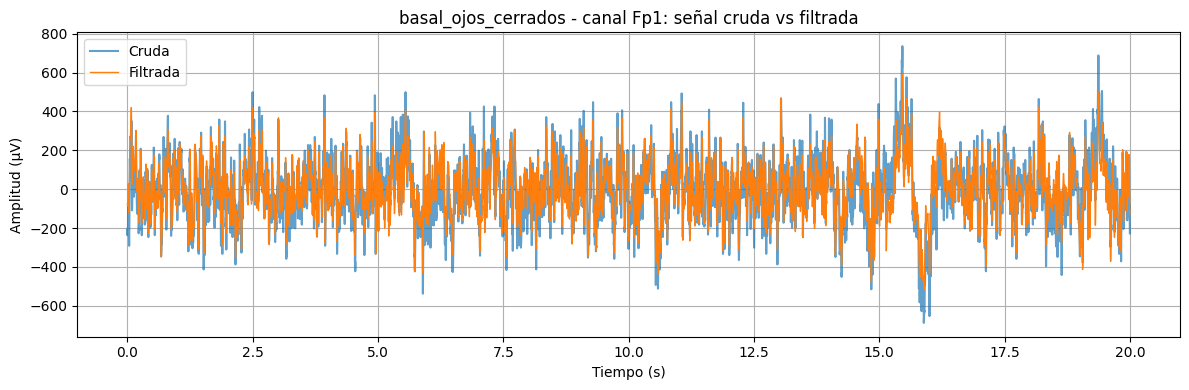

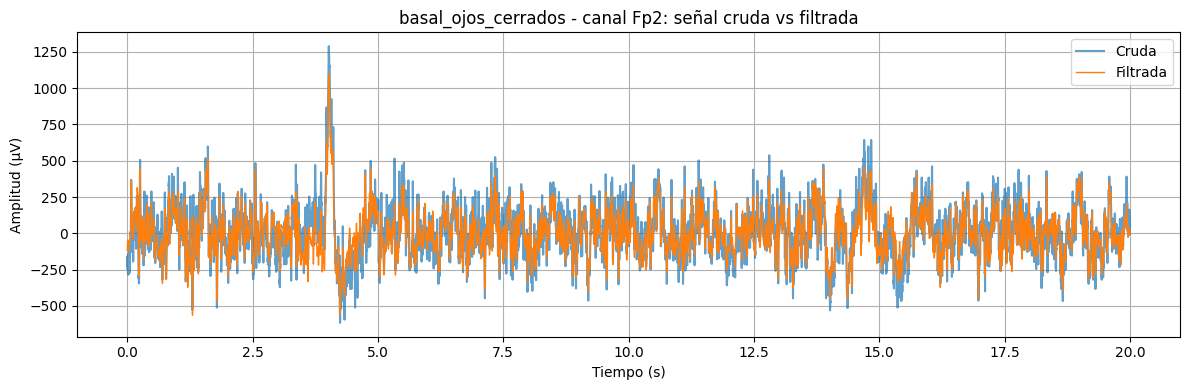

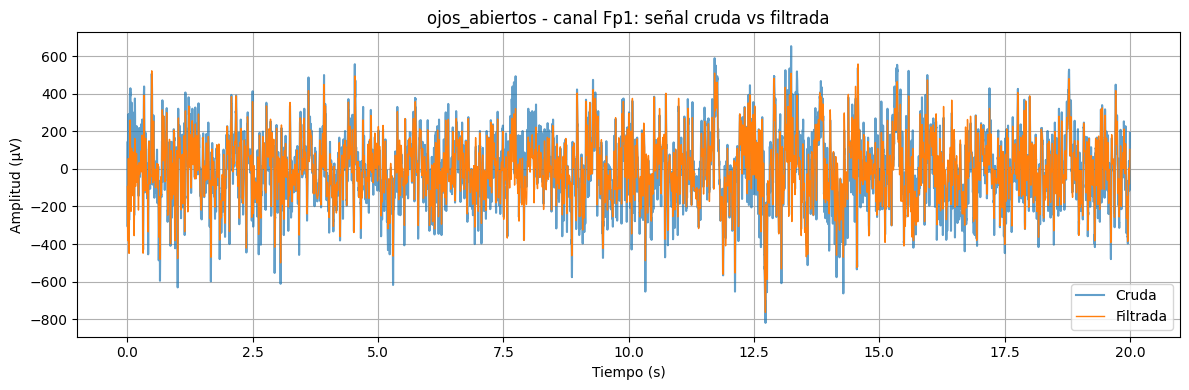

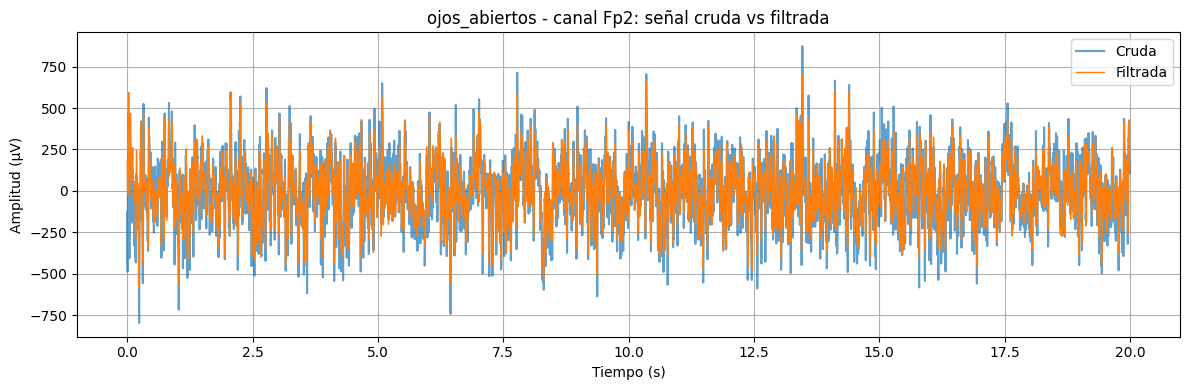

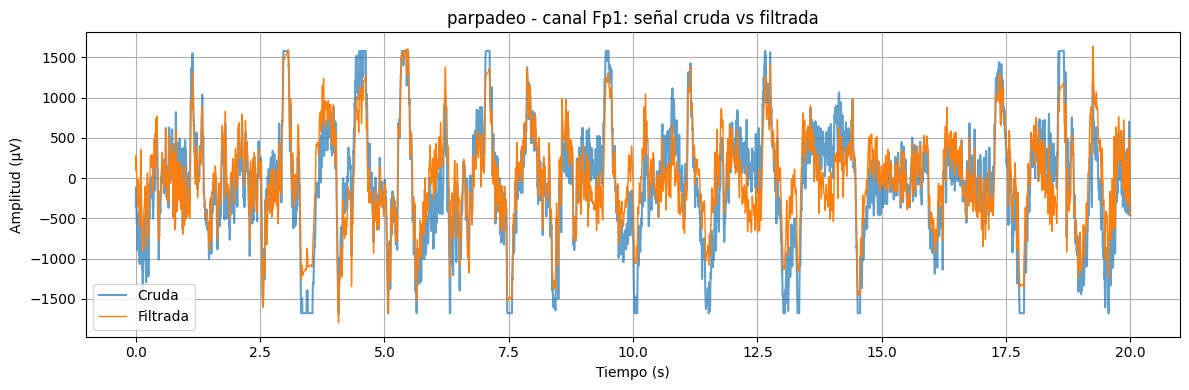

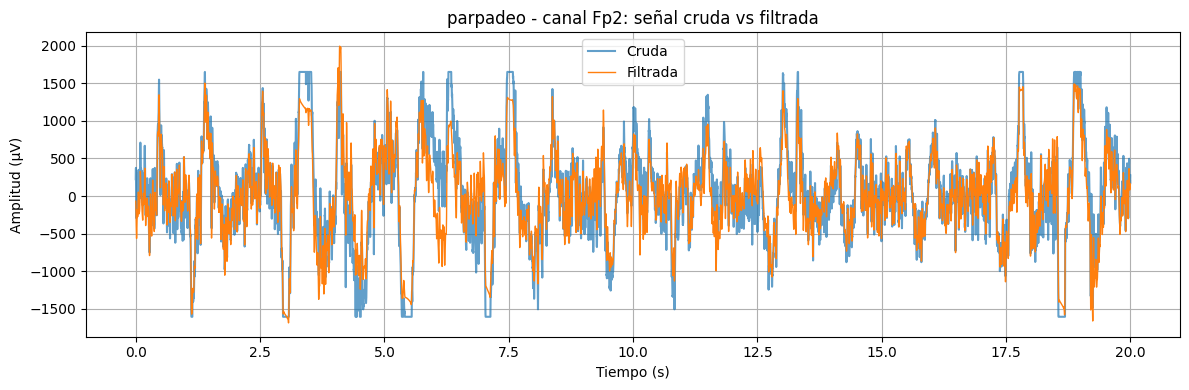

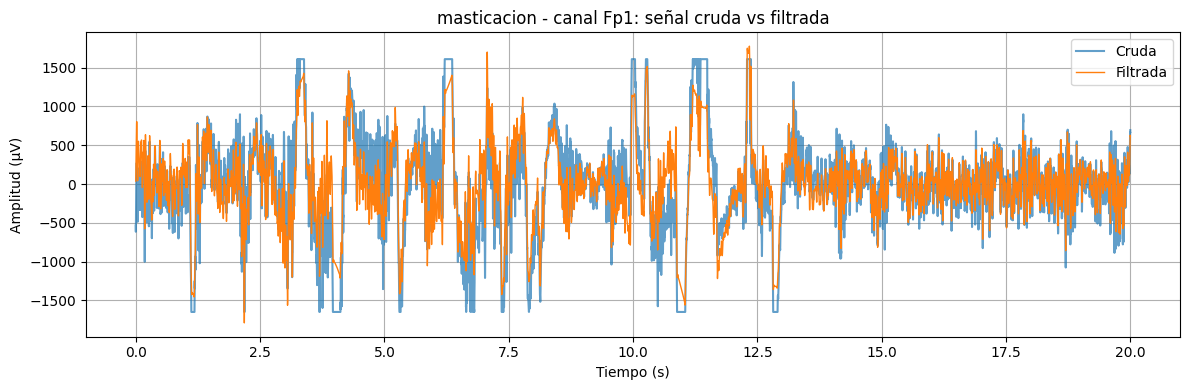

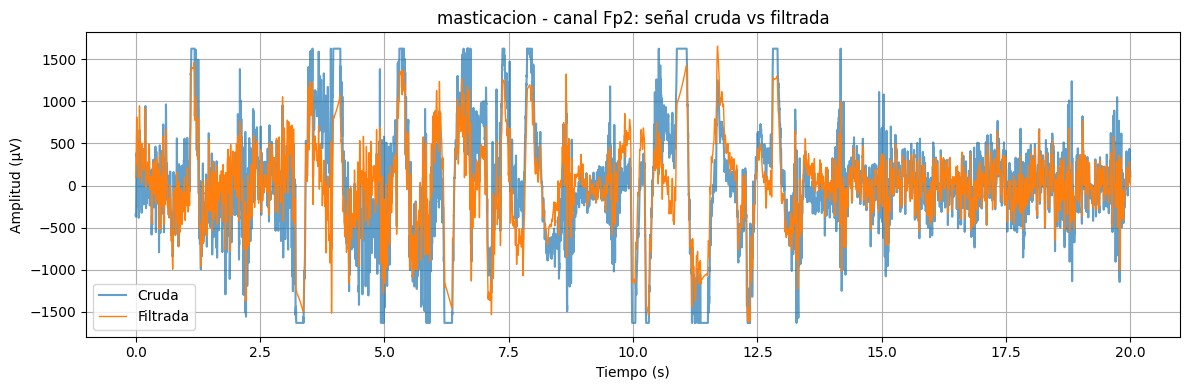

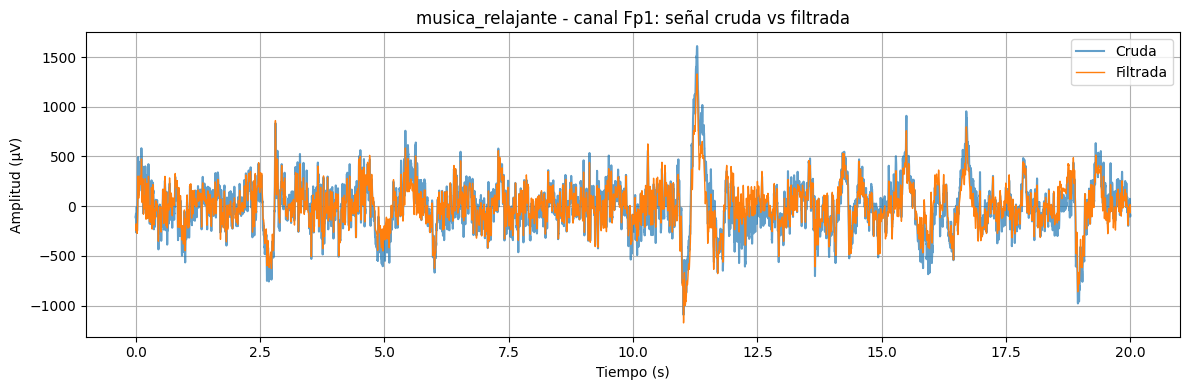

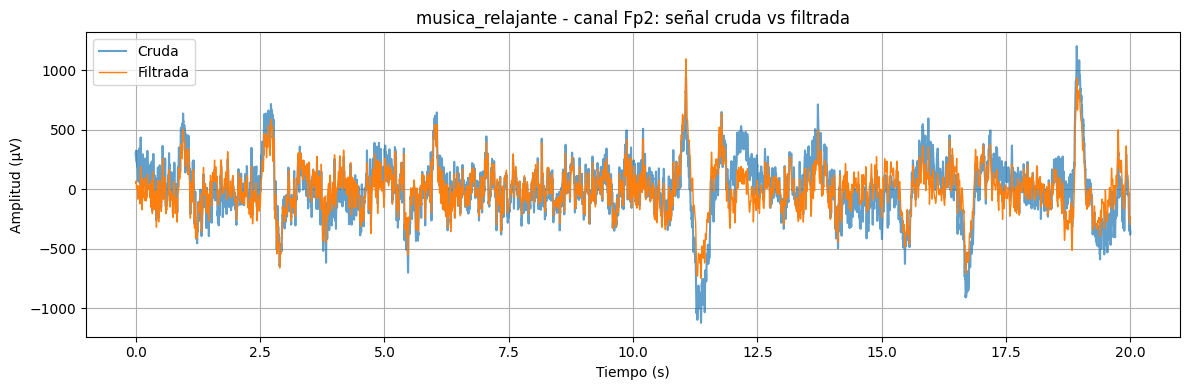

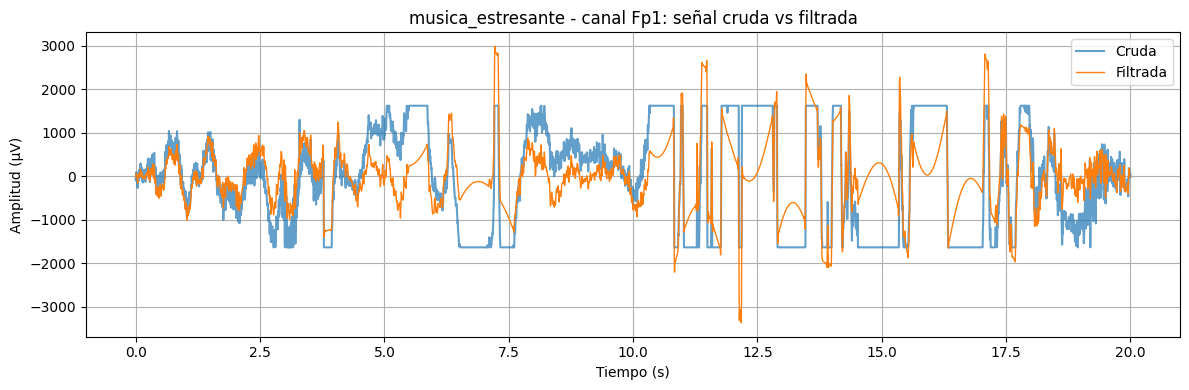

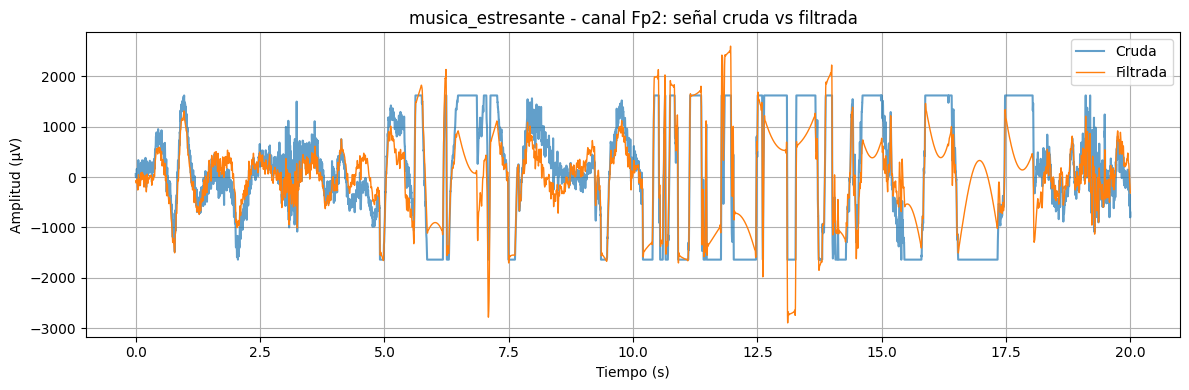

In [ ]:
def plot_condition_raw_vs_filtered(condition, tmax=None):
    raw = raw_data[condition]
    filt = filtered_data[condition]
    channels = [c for c in raw.columns if c != "time_s"]

    if tmax is None:
        idx = np.ones(len(raw), dtype=bool)
    else:
        idx = raw["time_s"] <= tmax

    for ch in channels:
        plt.figure(figsize=(12, 4))
        plt.plot(raw.loc[idx, "time_s"], raw.loc[idx, ch], label="Cruda", alpha=0.7)
        plt.plot(filt.loc[idx, "time_s"], filt.loc[idx, ch], label="Filtrada", linewidth=1)
        plt.xlabel("Tiempo (s)")
        plt.ylabel("Amplitud (µV)")
        plt.title(f"{condition} - canal {ch}: señal cruda vs filtrada")
        plt.legend()
        plt.tight_layout()

        out_path = FIG_DIR / f"{condition}_{ch}_raw_vs_filtrada.png"
        plt.savefig(out_path, dpi=200)
        plt.show()

# Graficar primeros 20 segundos de cada condición para revisión visual
for condition in FILES.keys():
    plot_condition_raw_vs_filtered(condition, tmax=20)

## 6. PSD de Welch por condición

Se calcula la densidad espectral de potencia usando Welch con segmento de 2 s.  
Esto permite observar qué frecuencias tienen mayor contribución en cada condición.

Las figuras se guardan en `outputs/figures/`.

In [ ]:
psd_rows = []

for condition, df in filtered_data.items():
    channels = [c for c in df.columns if c != "time_s"]

    for ch in channels:
        x = df[ch].to_numpy(dtype=float)
        f, pxx = compute_welch_psd(
            x,
            FS_HZ,
            nperseg_sec=WELCH_NPERSEG_SEC,
            overlap_sec=WELCH_OVERLAP_SEC
        )

        for fi, pi in zip(f, pxx):
            psd_rows.append({
                "condition": condition,
                "channel": ch,
                "frequency_hz": fi,
                "psd_uv2_per_hz": pi
            })

psd_df = pd.DataFrame(psd_rows)
psd_df.to_csv(TABLE_DIR / "psd_welch_por_condicion.csv", index=False)
psd_df.head()

,condition,channel,frequency_hz,psd_uv2_per_hz
0,basal_ojos_cerrados,Fp1,0.0,437.023856
1,basal_ojos_cerrados,Fp1,0.5,3158.686066
2,basal_ojos_cerrados,Fp1,1.0,15720.109946
3,basal_ojos_cerrados,Fp1,1.5,13457.445632
4,basal_ojos_cerrados,Fp1,2.0,5207.903244


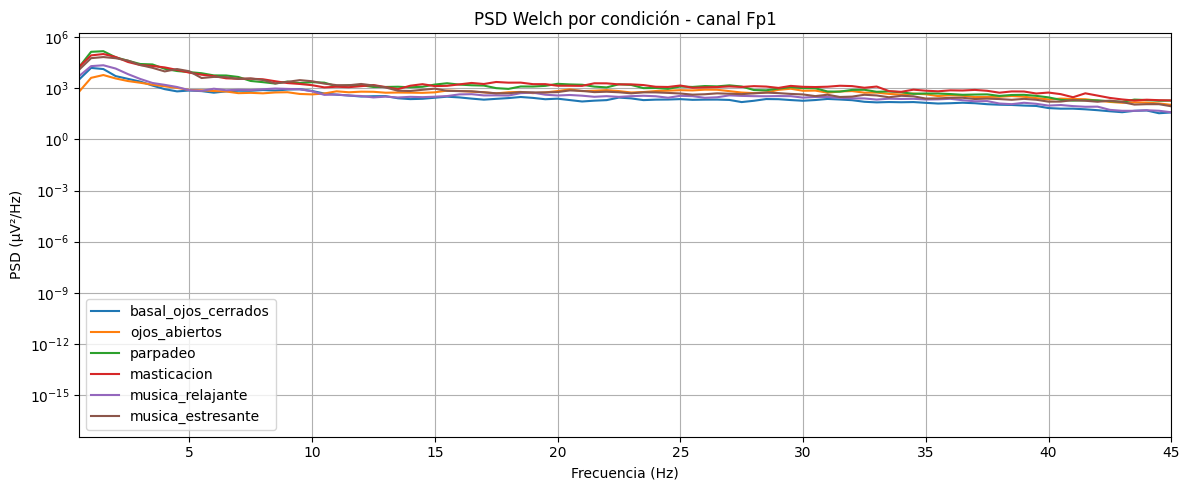

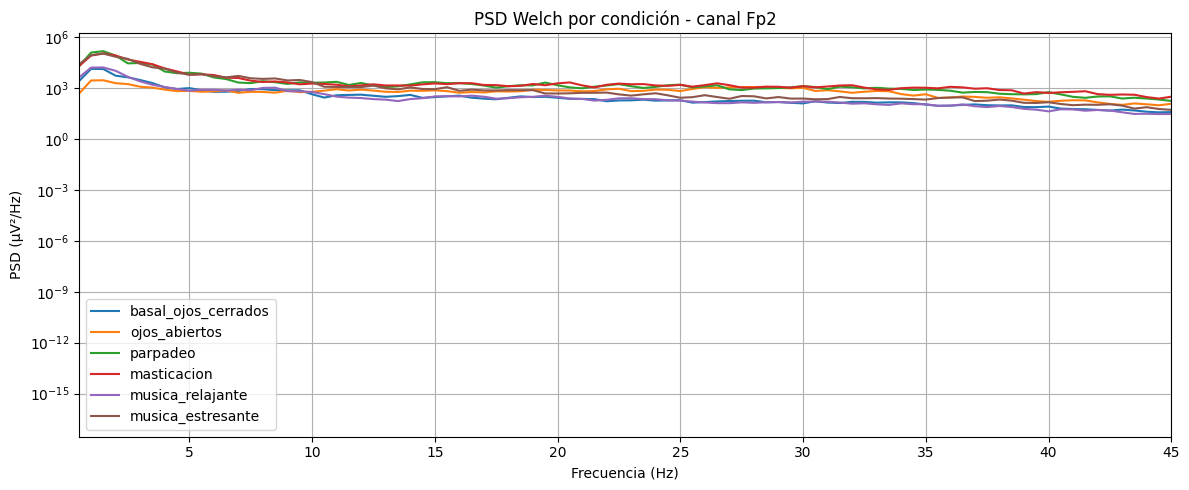

In [ ]:
# Graficar PSD por canal comparando todas las condiciones
channels = sorted(psd_df["channel"].unique())

for ch in channels:
    plt.figure(figsize=(12, 5))

    for condition in FILES.keys():
        sub = psd_df[(psd_df["condition"] == condition) & (psd_df["channel"] == ch)]
        plt.semilogy(sub["frequency_hz"], sub["psd_uv2_per_hz"], label=condition)

    plt.xlim(0.5, 45)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("PSD (µV²/Hz)")
    plt.title(f"PSD Welch por condición - canal {ch}")
    plt.legend()
    plt.tight_layout()

    out_path = FIG_DIR / f"PSD_Welch_comparacion_{ch}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

## 7. Potencia por bandas EEG

Se calcula la potencia absoluta y relativa por ventanas de 2 s en las bandas:

- Delta: 0.5-4 Hz
- Theta: 4-8 Hz
- Alfa: 8-13 Hz
- Beta: 13-30 Hz
- Gamma: 30-45 Hz

La tabla se guarda en `outputs/tables/potencia_bandas_por_epoca.csv`.

In [ ]:
bandpower_tables = []

for condition, df in filtered_data.items():
    bp = bandpower_by_epochs(
        eeg_df=df,
        condition_name=condition,
        fs=FS_HZ,
        bands=BANDS,
        epoch_sec=EPOCH_SEC
    )
    bandpower_tables.append(bp)

bandpower_df = pd.concat(bandpower_tables, ignore_index=True)
bandpower_df.to_csv(TABLE_DIR / "potencia_bandas_por_epoca.csv", index=False)

bandpower_df.head()

/tmp/ipykernel_14465/1879458442.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], f[idx])


,condition,channel,epoch,start_s,end_s,total_0p5_45,delta_abs,delta_rel,theta_abs,theta_rel,alpha_abs,alpha_rel,beta_abs,beta_rel,gamma_abs,gamma_rel
0,basal_ojos_cerrados,Fp1,0,0.0,2.0,18479.393655,4054.754689,0.219420,2118.745596,0.114654,6240.553402,0.337703,4665.708669,0.252482,1399.631298,0.075740
1,basal_ojos_cerrados,Fp1,1,2.0,4.0,13994.945209,2568.177705,0.183508,2145.192898,0.153283,3240.715301,0.231563,3746.363424,0.267694,2294.495881,0.163952
2,basal_ojos_cerrados,Fp1,2,4.0,6.0,14489.170997,2516.550640,0.173685,1496.370164,0.103275,2020.686940,0.139462,6198.331338,0.427791,2257.231914,0.155788
3,basal_ojos_cerrados,Fp1,3,6.0,8.0,17679.121560,5596.615296,0.316566,2646.820650,0.149714,2976.458150,0.168360,4711.065039,0.266476,1748.162425,0.098883
4,basal_ojos_cerrados,Fp1,4,8.0,10.0,19451.141091,3349.757999,0.172214,4178.435867,0.214817,2694.933644,0.138549,5874.245468,0.302000,3353.768113,0.172420


In [ ]:
# Resumen por condición y canal
summary_cols = []
for band in BANDS.keys():
    summary_cols.extend([f"{band}_abs", f"{band}_rel"])

summary_bandpower = (
    bandpower_df
    .groupby(["condition", "channel"])[summary_cols]
    .agg(["mean", "std", "median"])
    .reset_index()
)

summary_bandpower.to_csv(TABLE_DIR / "resumen_potencia_bandas.csv", index=False)
summary_bandpower

condition channel      delta_abs                                \
                                          mean            std         median   
0   basal_ojos_cerrados     Fp1   15880.815570   33578.581016    5612.797624   
1   basal_ojos_cerrados     Fp2   15561.309146   22866.638706    7185.016966   
2           masticacion     Fp1  153522.503107  186281.702434   53382.470622   
3           masticacion     Fp2  173200.456029  190699.231611   80874.725980   
4     musica_estresante     Fp1  133804.258662  210529.883238   40499.192304   
5     musica_estresante     Fp2  184730.427646  346937.310135   59053.522197   
6      musica_relajante     Fp1   32409.293123   48761.984981   12011.948188   
7      musica_relajante     Fp2   25699.102546   33481.828360   10472.102881   
8         ojos_abiertos     Fp1    7921.476644    4433.387455    6877.161356   
9         ojos_abiertos     Fp2    5510.160021    2557.084716    4549.331733   
10             parpadeo     Fp1  241227.559817  156375.846458  195942.155231   
11             parpadeo     Fp2  238295.177617  228327.063613  159875.991730   

   delta_rel                         theta_abs                ...  \
        mean       std    median          mean           std  ...   
0   0.395449  0.236799  0.316670   2574.275999   1225.598866  ...   
1   0.454826  0.222898  0.427792   2923.347088   1559.505527  ...   
2   0.540567  0.255140  0.543654  19363.641920  20829.551523  ...   
3   0.541280  0.268636  0.521677  17166.665159  15154.107919  ...   
4   0.624051  0.234061  0.696151  29991.865250  83288.835800  ...   
5   0.662577  0.220247  0.695488  25428.052826  53613.239505  ...   
6   0.514317  0.210131  0.463417   3801.580343   3313.171449  ...   
7   0.551140  0.221938  0.529441   3286.348093   1980.711323  ...   
8   0.248353  0.075651  0.247816   2770.705667   1902.610474  ...   
9   0.189950  0.071022  0.171335   2399.398693   1069.558339  ...   
10  0.739321  0.123949  0.772938  30675.536186  17535.032777  ...   
11  0.676460  0.167824  0.718265  22018.352841  11032.437902  ...   

        beta_abs  beta_rel                         gamma_abs               \
          median      mean       std    median          mean          std   
0    4265.168534  0.222540  0.096620  0.211457   1763.415577   557.718888   
1    3737.610499  0.204540  0.098595  0.199751   1394.552830   509.653268   
2   22867.939756  0.219814  0.183076  0.181712  10034.941064  5122.357685   
3   22773.962870  0.222176  0.167250  0.197706  12226.335142  5872.869418   
4    5202.434672  0.122419  0.121655  0.062942   3899.366551  3982.919914   
5    4214.145197  0.085033  0.083175  0.057635   2813.933041  3999.843706   
6    6075.855031  0.208013  0.114232  0.212658   2555.453300   894.271282   
7    3643.722061  0.166637  0.096605  0.158734   1145.306112   312.415815   
8   10844.032164  0.391299  0.089197  0.382315   5496.359953  3619.668578   
9   12033.426802  0.448651  0.082752  0.448016   4706.677318  2042.406215   
10  20433.403640  0.090533  0.049059  0.084479   6282.154101  1863.922533   
11  22812.736167  0.135791  0.103935  0.102621   9711.882089  3558.713881   

                 gamma_rel                      
          median      mean       std    median  
0    1747.394817  0.099856  0.048729  0.098172  
1    1377.836954  0.073511  0.041938  0.067176  
2    8018.802820  0.085255  0.063166  0.081405  
3   12382.853248  0.104580  0.081034  0.096270  
4    2222.055093  0.063291  0.079042  0.024977  
5    1500.117198  0.040947  0.051999  0.015984  
6    2323.146502  0.087625  0.051290  0.100552  
7    1193.128051  0.050052  0.027469  0.054161  
8    4976.812055  0.172558  0.061315  0.179925  
9    4276.167950  0.160319  0.050900  0.146777  
10   5641.009424  0.024991  0.013216  0.023544  
11   8523.996743  0.052763  0.037390  0.038833  

[12 rows x 32 columns]

## 8. Comparación de potencia alfa: ojos cerrados vs ojos abiertos

Esta sección responde al ejercicio:

> Comparar potencia α en ojos abiertos vs. cerrados usando PSD Welch con ventanas de 2 s.

Se usa la condición basal como equivalente de **ojos cerrados / aislamiento parcial** y se compara contra la condición **ojos abiertos**.

La comparación se realiza con potencia alfa absoluta y relativa por ventanas de 2 s.

In [ ]:
def paired_test_between_conditions(df, cond_a, cond_b, metric, label_a="A", label_b="B"):
    """
    Hace t-test pareado entre dos condiciones usando ventanas emparejadas por orden.
    Si las condiciones tienen diferente número de ventanas, recorta a la menor cantidad.
    """
    rows = []

    for ch in sorted(df["channel"].unique()):
        a = df[(df["condition"] == cond_a) & (df["channel"] == ch)][metric].dropna().to_numpy()
        b = df[(df["condition"] == cond_b) & (df["channel"] == ch)][metric].dropna().to_numpy()

        n = min(len(a), len(b))
        if n < 2:
            rows.append({
                "channel": ch,
                "metric": metric,
                "condition_a": cond_a,
                "condition_b": cond_b,
                "n_pairs": n,
                "mean_a": np.nanmean(a) if len(a) else np.nan,
                "mean_b": np.nanmean(b) if len(b) else np.nan,
                "t_stat": np.nan,
                "p_value": np.nan,
                "interpretation": "No hay suficientes ventanas para t-test."
            })
            continue

        a = a[:n]
        b = b[:n]

        test = ttest_rel(a, b, nan_policy="omit")
        diff = np.nanmean(a - b)

        if test.pvalue < 0.05:
            if diff > 0:
                interp = f"Diferencia significativa: {label_a} > {label_b}."
            else:
                interp = f"Diferencia significativa: {label_b} > {label_a}."
        else:
            interp = "No se encontró diferencia significativa al 5%."

        rows.append({
            "channel": ch,
            "metric": metric,
            "condition_a": cond_a,
            "condition_b": cond_b,
            "n_pairs": n,
            "mean_a": float(np.nanmean(a)),
            "std_a": float(np.nanstd(a, ddof=1)),
            "mean_b": float(np.nanmean(b)),
            "std_b": float(np.nanstd(b, ddof=1)),
            "mean_diff_a_minus_b": float(diff),
            "t_stat": float(test.statistic),
            "p_value": float(test.pvalue),
            "interpretation": interp
        })

    return pd.DataFrame(rows)

alpha_abs_test = paired_test_between_conditions(
    bandpower_df,
    ALPHA_CLOSED_CONDITION,
    ALPHA_OPEN_CONDITION,
    "alpha_abs",
    label_a="ojos cerrados/basal",
    label_b="ojos abiertos"
)

alpha_rel_test = paired_test_between_conditions(
    bandpower_df,
    ALPHA_CLOSED_CONDITION,
    ALPHA_OPEN_CONDITION,
    "alpha_rel",
    label_a="ojos cerrados/basal",
    label_b="ojos abiertos"
)

alpha_tests = pd.concat([
    alpha_abs_test.assign(test_type="alpha_abs"),
    alpha_rel_test.assign(test_type="alpha_rel")
], ignore_index=True)

alpha_tests.to_csv(TABLE_DIR / "test_alpha_ojos_cerrados_vs_abiertos.csv", index=False)
alpha_tests

,channel,metric,condition_a,condition_b,n_pairs,mean_a,std_a,mean_b,std_b,mean_diff_a_minus_b,t_stat,p_value,interpretation,test_type
0,Fp1,alpha_abs,basal_ojos_cerrados,ojos_abiertos,30,2727.942081,1071.578203,2894.763018,1818.993800,-166.820936,-0.410984,0.684106,No se encontró diferencia significativa al 5%.,alpha_abs
1,Fp2,alpha_abs,basal_ojos_cerrados,ojos_abiertos,30,2383.148374,896.988368,3238.087425,1713.995211,-854.939050,-2.688212,0.011777,Diferencia significativa: ojos abiertos > ojos...,alpha_abs
2,Fp1,alpha_rel,basal_ojos_cerrados,ojos_abiertos,30,0.147966,0.077945,0.096136,0.046416,0.051830,3.344863,0.002286,Diferencia significativa: ojos cerrados/basal ...,alpha_rel
3,Fp2,alpha_rel,basal_ojos_cerrados,ojos_abiertos,30,0.121538,0.056795,0.113346,0.052526,0.008192,0.674159,0.505549,No se encontró diferencia significativa al 5%.,alpha_rel


/tmp/ipykernel_14465/3014778000.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Ojos cerrados/basal", "Ojos abiertos"])


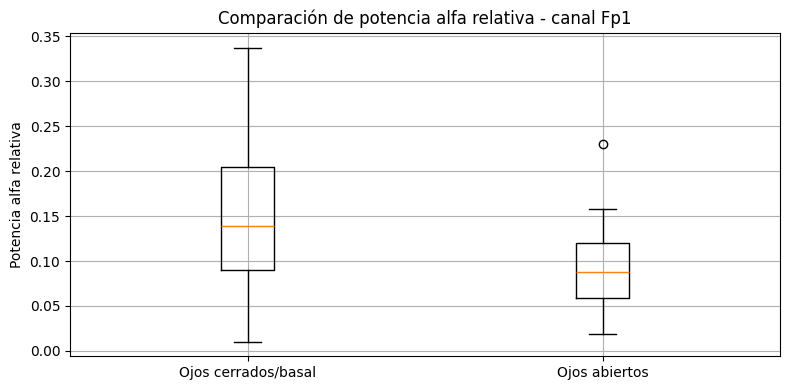

/tmp/ipykernel_14465/3014778000.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Ojos cerrados/basal", "Ojos abiertos"])


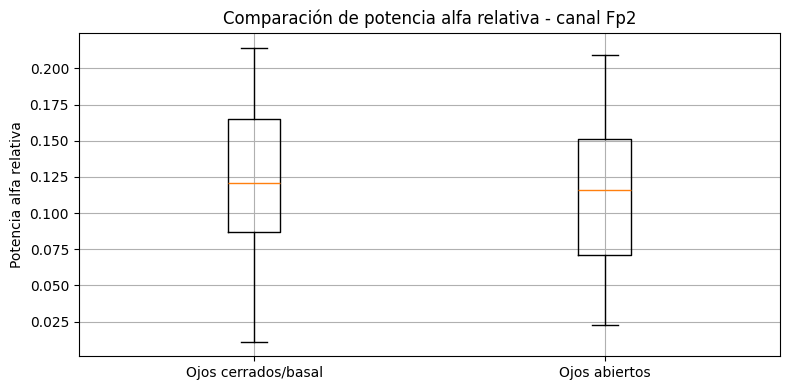

In [ ]:
# Gráfico comparativo de alfa relativa por canal
for ch in sorted(bandpower_df["channel"].unique()):
    sub = bandpower_df[
        (bandpower_df["channel"] == ch) &
        (bandpower_df["condition"].isin([ALPHA_CLOSED_CONDITION, ALPHA_OPEN_CONDITION]))
    ]

    plt.figure(figsize=(8, 4))
    data_to_plot = [
        sub[sub["condition"] == ALPHA_CLOSED_CONDITION]["alpha_rel"].dropna(),
        sub[sub["condition"] == ALPHA_OPEN_CONDITION]["alpha_rel"].dropna(),
    ]

    plt.boxplot(data_to_plot, labels=["Ojos cerrados/basal", "Ojos abiertos"])
    plt.ylabel("Potencia alfa relativa")
    plt.title(f"Comparación de potencia alfa relativa - canal {ch}")
    plt.tight_layout()

    out_path = FIG_DIR / f"alpha_rel_ojos_cerrados_vs_abiertos_{ch}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

## 9. Incremento de beta durante condición de carga/estrés

Esta sección responde al ejercicio:

> Evaluar incremento de β durante la tarea cognitiva usando t-test pareado.

Como el protocolo descrito no incluye una tarea cognitiva clásica, este notebook usa por defecto:

- Condición basal/comparación: `musica_relajante`
- Condición de carga/estrés: `musica_estresante`

Si el profesor solicita estrictamente “tarea cognitiva”, cambia `BETA_TASK_CONDITION` por el archivo correspondiente.

In [ ]:
beta_abs_test = paired_test_between_conditions(
    bandpower_df,
    BETA_BASELINE_CONDITION,
    BETA_TASK_CONDITION,
    "beta_abs",
    label_a=BETA_BASELINE_CONDITION,
    label_b=BETA_TASK_CONDITION
)

beta_rel_test = paired_test_between_conditions(
    bandpower_df,
    BETA_BASELINE_CONDITION,
    BETA_TASK_CONDITION,
    "beta_rel",
    label_a=BETA_BASELINE_CONDITION,
    label_b=BETA_TASK_CONDITION
)

beta_tests = pd.concat([
    beta_abs_test.assign(test_type="beta_abs"),
    beta_rel_test.assign(test_type="beta_rel")
], ignore_index=True)

beta_tests.to_csv(TABLE_DIR / "test_beta_relajante_vs_estresante.csv", index=False)
beta_tests

,channel,metric,condition_a,condition_b,n_pairs,mean_a,std_a,mean_b,std_b,mean_diff_a_minus_b,t_stat,p_value,interpretation,test_type
0,Fp1,beta_abs,musica_relajante,musica_estresante,33,6544.874215,2433.129731,11067.407815,13726.810495,-4522.533600,-1.954795,0.059391,No se encontró diferencia significativa al 5%.,beta_abs
1,Fp2,beta_abs,musica_relajante,musica_estresante,33,3742.874974,1128.338407,11542.928021,20932.235774,-7800.053047,-2.145047,0.039641,Diferencia significativa: musica_estresante > ...,beta_abs
2,Fp1,beta_rel,musica_relajante,musica_estresante,33,0.208013,0.114232,0.087819,0.078278,0.120195,5.201650,0.000011,Diferencia significativa: musica_relajante > m...,beta_rel
3,Fp2,beta_rel,musica_relajante,musica_estresante,33,0.166637,0.096605,0.069289,0.068142,0.097348,4.475407,0.000091,Diferencia significativa: musica_relajante > m...,beta_rel


/tmp/ipykernel_14465/3191582277.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[BETA_BASELINE_CONDITION, BETA_TASK_CONDITION])


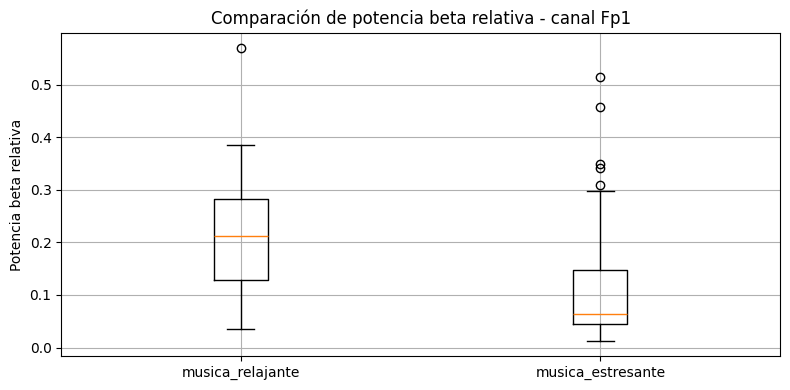

/tmp/ipykernel_14465/3191582277.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[BETA_BASELINE_CONDITION, BETA_TASK_CONDITION])


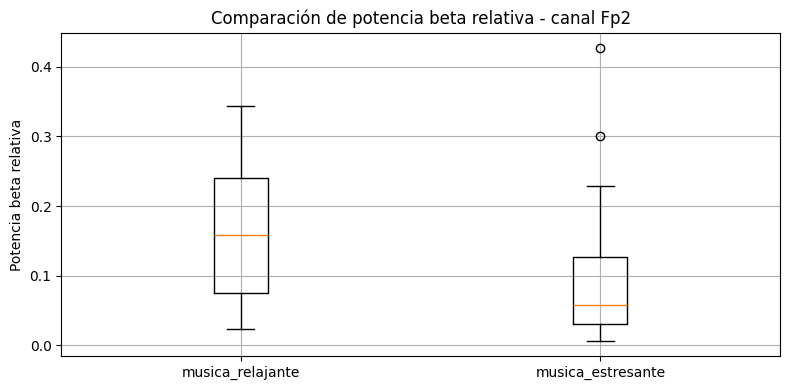

In [ ]:
# Gráfico comparativo de beta relativa por canal
for ch in sorted(bandpower_df["channel"].unique()):
    sub = bandpower_df[
        (bandpower_df["channel"] == ch) &
        (bandpower_df["condition"].isin([BETA_BASELINE_CONDITION, BETA_TASK_CONDITION]))
    ]

    plt.figure(figsize=(8, 4))
    data_to_plot = [
        sub[sub["condition"] == BETA_BASELINE_CONDITION]["beta_rel"].dropna(),
        sub[sub["condition"] == BETA_TASK_CONDITION]["beta_rel"].dropna(),
    ]

    plt.boxplot(data_to_plot, labels=[BETA_BASELINE_CONDITION, BETA_TASK_CONDITION])
    plt.ylabel("Potencia beta relativa")
    plt.title(f"Comparación de potencia beta relativa - canal {ch}")
    plt.tight_layout()

    out_path = FIG_DIR / f"beta_rel_{BETA_BASELINE_CONDITION}_vs_{BETA_TASK_CONDITION}_{ch}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

## 10. Detección de artefactos de parpadeo

Esta sección responde al ejercicio:

> Detectar artefactos de parpadeo mayores a 80 µV y contabilizar su número.

El algoritmo busca picos en la señal centrada respecto a su mediana.  
Se contabilizan picos cuya amplitud absoluta supere `80 µV`, separados al menos `0.25 s`.

In [ ]:
blink_df = detect_blinks(
    filtered_data["parpadeo"],
    threshold_uv=BLINK_THRESHOLD_UV,
    min_distance_sec=BLINK_MIN_DISTANCE_SEC
)

blink_df.to_csv(TABLE_DIR / "artefactos_parpadeo_detectados.csv", index=False)

if len(blink_df) > 0:
    blink_counts = (
        blink_df
        .groupby("channel")
        .size()
        .reset_index(name="n_blinks_detected")
    )
else:
    blink_counts = pd.DataFrame(columns=["channel", "n_blinks_detected"])

blink_counts.to_csv(TABLE_DIR / "conteo_artefactos_parpadeo.csv", index=False)
blink_counts

,channel,n_blinks_detected
0,Fp1,92
1,Fp2,94


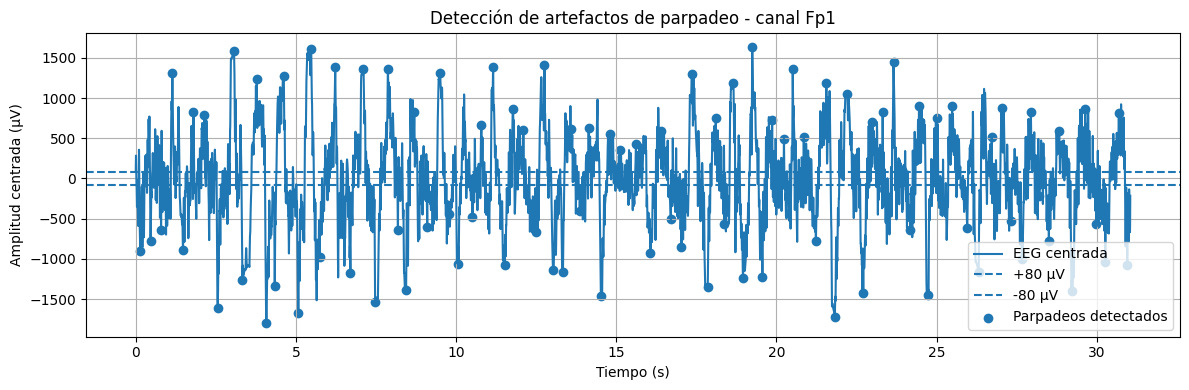

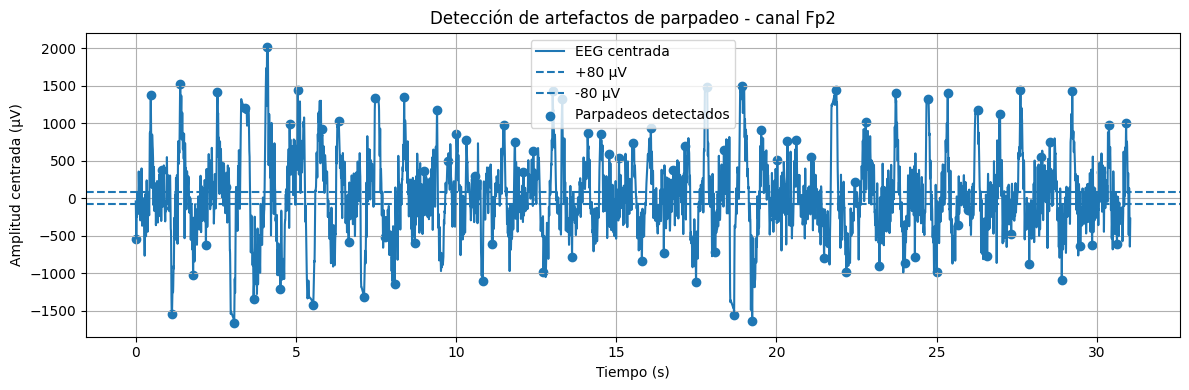

In [ ]:
# Graficar parpadeos detectados
parp = filtered_data["parpadeo"]

for ch in [c for c in parp.columns if c != "time_s"]:
    x = parp[ch].to_numpy(dtype=float)
    t = parp["time_s"].to_numpy(dtype=float)

    sub_events = blink_df[blink_df["channel"] == ch] if len(blink_df) else pd.DataFrame()

    plt.figure(figsize=(12, 4))
    plt.plot(t, x - np.nanmedian(x), label="EEG centrada")
    plt.axhline(BLINK_THRESHOLD_UV, linestyle="--", label="+80 µV")
    plt.axhline(-BLINK_THRESHOLD_UV, linestyle="--", label="-80 µV")

    if len(sub_events) > 0:
        plt.scatter(
            sub_events["time_s"],
            sub_events["signed_amplitude_uv"],
            marker="o",
            label="Parpadeos detectados"
        )

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud centrada (µV)")
    plt.title(f"Detección de artefactos de parpadeo - canal {ch}")
    plt.legend()
    plt.tight_layout()

    out_path = FIG_DIR / f"parpadeos_detectados_{ch}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

## 11. Comparación Fp1 vs Fp2, si tienen dos canales

Esta sección solo aplica si en `EEG_COLUMN_INDICES` configuraste dos canales, por ejemplo:

```python
EEG_COLUMN_INDICES = {"Fp1": -2, "Fp2": -1}
```

La comparación se hace por potencia relativa de bandas.

,condition,channel,alpha_rel,beta_rel,theta_rel
0,basal_ojos_cerrados,Fp1,0.147966,0.222540,0.134190
1,basal_ojos_cerrados,Fp2,0.121538,0.204540,0.145585
2,masticacion,Fp1,0.058185,0.219814,0.096180
3,masticacion,Fp2,0.051341,0.222176,0.080622
4,musica_estresante,Fp1,0.074286,0.122419,0.115953
5,musica_estresante,Fp2,0.086144,0.085033,0.125299
6,musica_relajante,Fp1,0.093421,0.208013,0.096624
7,musica_relajante,Fp2,0.103861,0.166637,0.128311
8,ojos_abiertos,Fp1,0.095323,0.391299,0.092467
9,ojos_abiertos,Fp2,0.111708,0.448651,0.089372


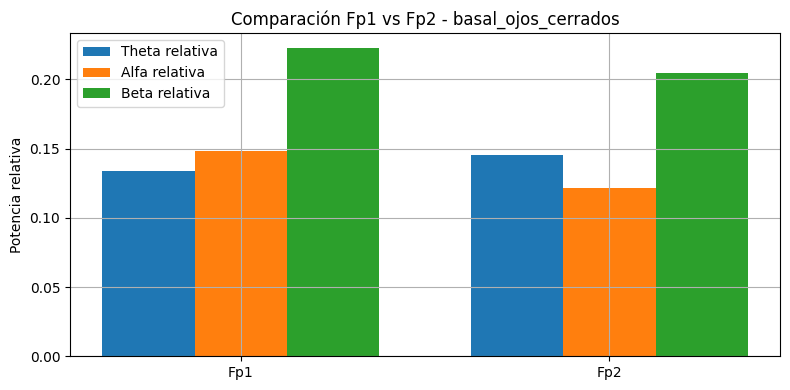

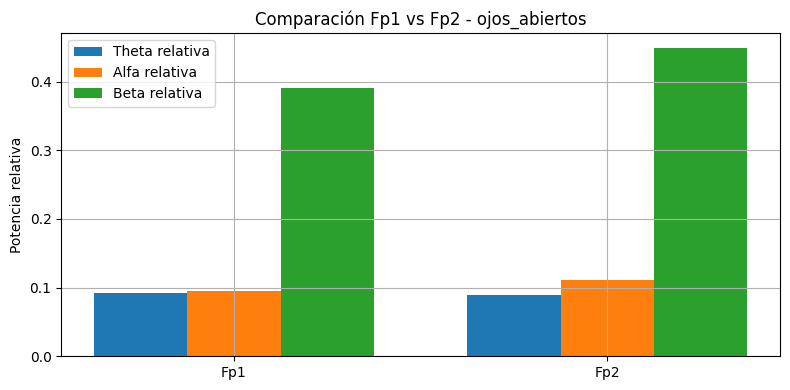

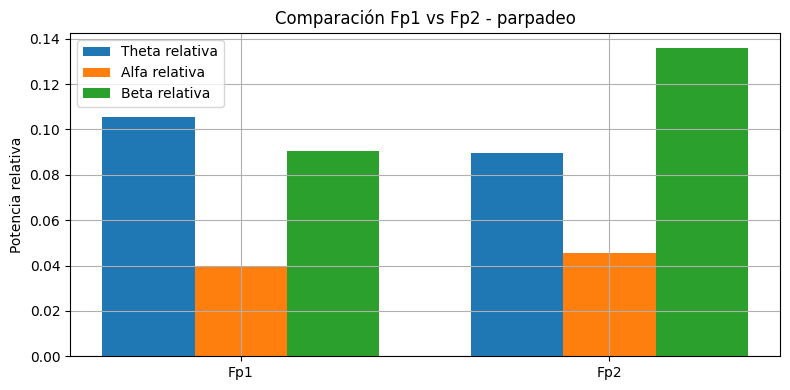

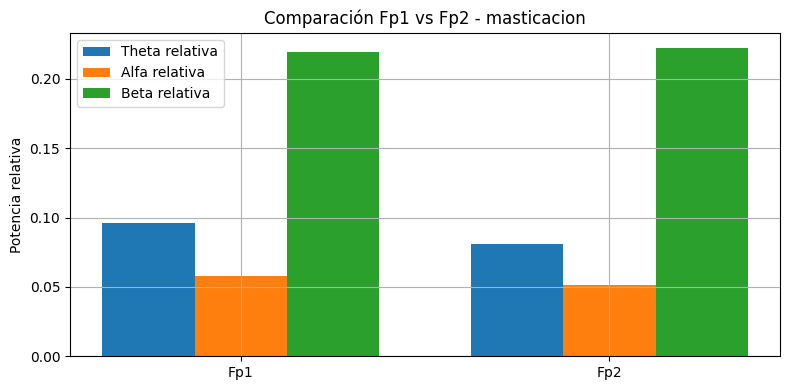

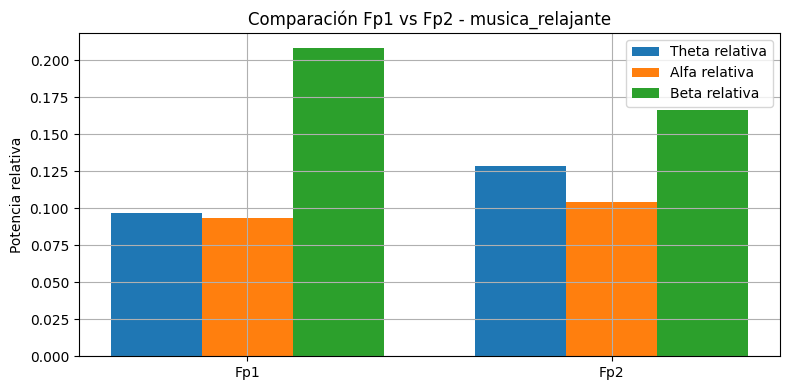

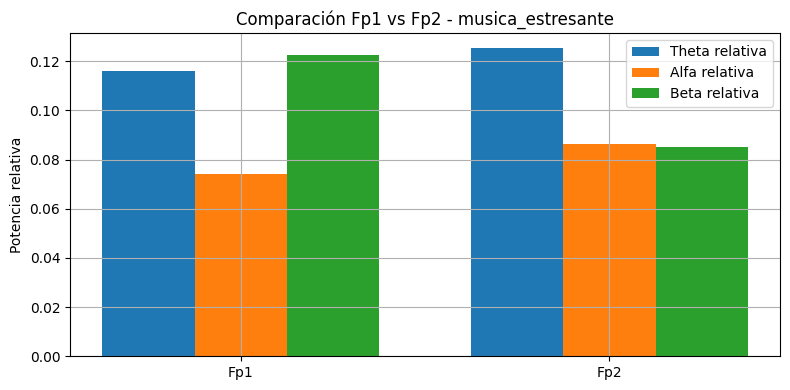

In [ ]:
channels_available = sorted(bandpower_df["channel"].unique())

if set(["Fp1", "Fp2"]).issubset(set(channels_available)):
    fp_summary = (
        bandpower_df[bandpower_df["channel"].isin(["Fp1", "Fp2"])]
        .groupby(["condition", "channel"])[["alpha_rel", "beta_rel", "theta_rel"]]
        .mean()
        .reset_index()
    )
    fp_summary.to_csv(TABLE_DIR / "comparacion_Fp1_Fp2.csv", index=False)
    display(fp_summary)

    for condition in FILES.keys():
        sub = fp_summary[fp_summary["condition"] == condition]
        plt.figure(figsize=(8, 4))
        x = np.arange(len(sub["channel"]))
        width = 0.25

        plt.bar(x - width, sub["theta_rel"], width, label="Theta relativa")
        plt.bar(x, sub["alpha_rel"], width, label="Alfa relativa")
        plt.bar(x + width, sub["beta_rel"], width, label="Beta relativa")
        plt.xticks(x, sub["channel"])
        plt.ylabel("Potencia relativa")
        plt.title(f"Comparación Fp1 vs Fp2 - {condition}")
        plt.legend()
        plt.tight_layout()

        out_path = FIG_DIR / f"Fp1_vs_Fp2_{condition}.png"
        plt.savefig(out_path, dpi=200)
        plt.show()
else:
    print("No se detectaron canales llamados Fp1 y Fp2. Si los tienes, cambia EEG_COLUMN_INDICES al inicio del notebook.")

## 12. Tablas finales para el informe

Esta sección genera tablas compactas que puedes copiar a la sección **Resultados**.

In [ ]:
# Tabla compacta de potencia media relativa por condición y canal
relative_cols = [f"{band}_rel" for band in BANDS.keys()]

table_results = (
    bandpower_df
    .groupby(["condition", "channel"])[relative_cols]
    .mean()
    .reset_index()
)

table_results.to_csv(TABLE_DIR / "tabla_resultados_potencia_relativa.csv", index=False)
table_results

,condition,channel,delta_rel,theta_rel,alpha_rel,beta_rel,gamma_rel
0,basal_ojos_cerrados,Fp1,0.395449,0.134190,0.147966,0.222540,0.099856
1,basal_ojos_cerrados,Fp2,0.454826,0.145585,0.121538,0.204540,0.073511
2,masticacion,Fp1,0.540567,0.096180,0.058185,0.219814,0.085255
3,masticacion,Fp2,0.541280,0.080622,0.051341,0.222176,0.104580
4,musica_estresante,Fp1,0.624051,0.115953,0.074286,0.122419,0.063291
5,musica_estresante,Fp2,0.662577,0.125299,0.086144,0.085033,0.040947
6,musica_relajante,Fp1,0.514317,0.096624,0.093421,0.208013,0.087625
7,musica_relajante,Fp2,0.551140,0.128311,0.103861,0.166637,0.050052
8,ojos_abiertos,Fp1,0.248353,0.092467,0.095323,0.391299,0.172558
9,ojos_abiertos,Fp2,0.189950,0.089372,0.111708,0.448651,0.160319


In [ ]:
# Tabla de pruebas estadísticas principales
stats_results = pd.concat([
    alpha_tests.assign(analysis="alfa_ojos_cerrados_vs_abiertos"),
    beta_tests.assign(analysis="beta_relajante_vs_estresante")
], ignore_index=True)

stats_results.to_csv(TABLE_DIR / "tabla_pruebas_estadisticas.csv", index=False)

stats_results[[
    "analysis", "test_type", "channel", "n_pairs",
    "mean_a", "mean_b", "mean_diff_a_minus_b",
    "t_stat", "p_value", "interpretation"
]]

,analysis,test_type,channel,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,t_stat,p_value,interpretation
0,alfa_ojos_cerrados_vs_abiertos,alpha_abs,Fp1,30,2727.942081,2894.763018,-166.820936,-0.410984,0.684106,No se encontró diferencia significativa al 5%.
1,alfa_ojos_cerrados_vs_abiertos,alpha_abs,Fp2,30,2383.148374,3238.087425,-854.939050,-2.688212,0.011777,Diferencia significativa: ojos abiertos > ojos...
2,alfa_ojos_cerrados_vs_abiertos,alpha_rel,Fp1,30,0.147966,0.096136,0.051830,3.344863,0.002286,Diferencia significativa: ojos cerrados/basal ...
3,alfa_ojos_cerrados_vs_abiertos,alpha_rel,Fp2,30,0.121538,0.113346,0.008192,0.674159,0.505549,No se encontró diferencia significativa al 5%.
4,beta_relajante_vs_estresante,beta_abs,Fp1,33,6544.874215,11067.407815,-4522.533600,-1.954795,0.059391,No se encontró diferencia significativa al 5%.
5,beta_relajante_vs_estresante,beta_abs,Fp2,33,3742.874974,11542.928021,-7800.053047,-2.145047,0.039641,Diferencia significativa: musica_estresante > ...
6,beta_relajante_vs_estresante,beta_rel,Fp1,33,0.208013,0.087819,0.120195,5.201650,0.000011,Diferencia significativa: musica_relajante > m...
7,beta_relajante_vs_estresante,beta_rel,Fp2,33,0.166637,0.069289,0.097348,4.475407,0.000091,Diferencia significativa: musica_relajante > m...


## 13. Plantilla para discusión

Puedes usar este texto como base, pero debes reemplazar lo que está entre corchetes con tus resultados reales.

### ¿Qué banda de frecuencia predomina al cerrar los ojos?

En la condición basal con ojos cubiertos o cerrados se evaluó la potencia relativa de las bandas EEG. Según los resultados obtenidos, la banda predominante fue **[completar: alfa/theta/beta/etc.]**. En EEG, la banda alfa suele aumentar durante reposo con ojos cerrados, aunque este efecto puede observarse mejor en regiones posteriores que en derivaciones frontales.

### ¿Qué filtro es imprescindible para EEG y por qué?

Para EEG es imprescindible controlar el contenido de frecuencia mediante un **filtro pasa banda**, porque la señal EEG es de baja amplitud y puede contaminarse por deriva DC, movimiento y ruido de alta frecuencia. En este laboratorio, el canal EEG de BITalino ya incluye un filtro hardware de aproximadamente **0.8-48 Hz**, por lo que se atenúan componentes lentas y frecuencias por encima del rango EEG principal. Además, si aparece contaminación de red eléctrica, se puede usar un **filtro notch de 50/60 Hz**; sin embargo, en este caso puede no ser necesario porque el hardware ya limita la banda hasta aproximadamente 48 Hz.

### ¿Puedes modular conscientemente tu señal EEG? Da un ejemplo.

Sí, algunos patrones EEG pueden modificarse de manera consciente o voluntaria. Un ejemplo simple es **abrir y cerrar los ojos**: al cerrar los ojos, puede aumentar la actividad alfa en reposo. Otro ejemplo es el parpadeo, aunque este no representa modulación cerebral pura, sino un artefacto ocular claramente visible en la señal.

### ¿Se observan diferencias entre Fp1 y Fp2? ¿Por qué podrían ocurrir?

Si se adquirieron Fp1 y Fp2, las diferencias pueden deberse a varios factores: diferencias de impedancia entre electrodos, contacto desigual con la piel, asimetría en la colocación, actividad ocular lateralizada, actividad muscular facial o diferencias reales en la actividad registrada por cada derivación. Por ello, antes de interpretar diferencias fisiológicas, se debe verificar la calidad de la señal y la presencia de artefactos.

## 14. Conclusión operativa

Al finalizar la ejecución del notebook, revisa las siguientes carpetas:

```text
outputs/figures/
outputs/tables/
```

Para el informe, usa principalmente:

- `PSD_Welch_comparacion_*.png`
- `alpha_rel_ojos_cerrados_vs_abiertos_*.png`
- `beta_rel_musica_relajante_vs_musica_estresante_*.png`
- `parpadeos_detectados_*.png`
- `tabla_resultados_potencia_relativa.csv`
- `tabla_pruebas_estadisticas.csv`
- `conteo_artefactos_parpadeo.csv`

Estos archivos pueden colocarse en la sección **Resultados** y discutirse en función de las preguntas del laboratorio.